# 8.3 — Phân tích Thống kê (Full Experiment — Improved)



In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, confusion_matrix, accuracy_score, precision_score, recall_score
from statsmodels.stats.contingency_tables import mcnemar

pd.set_option('display.max_colwidth', 80)


## 1. Load dữ liệu thô 

In [2]:

llm_full = pd.read_csv('../results/full_llm_output_improved.csv', encoding='utf-8-sig')
gt_full  = pd.read_csv('../data/full_ground_truth_improved.csv', encoding='utf-8-sig')

llm = llm_full[['issue_key', 's2r_label', 'reason']].copy()
gt = gt_full[['BUG-ID', 'S2R Label', 'Reason']].copy()

print(f"full_llm_output_improved.csv    : {len(llm)} dòng, cột dùng = {list(llm.columns)}")
print(f"full_ground_truth_improved.csv  : {len(gt)} dòng, cột dùng = {list(gt.columns)}")
print()
print("Phân phối s2r_label (LLM):")
print(llm['s2r_label'].value_counts())
print()
print("Phân phối S2R Label (Người):")
print(gt['S2R Label'].value_counts())


full_llm_output_improved.csv    : 139 dòng, cột dùng = ['issue_key', 's2r_label', 'reason']
full_ground_truth_improved.csv  : 139 dòng, cột dùng = ['BUG-ID', 'S2R Label', 'Reason']

Phân phối s2r_label (LLM):
s2r_label
Executable        137
Non-Executable      2
Name: count, dtype: int64

Phân phối S2R Label (Người):
S2R Label
Executable        94
Non-Executable    45
Name: count, dtype: int64


## 2. Phạm vi thực tế được đánh giá

Chỉ có nhãn S2R được LLM dự đoán (`s2r_label`) — chưa có dự đoán cho `OB Label`/`EB Label`, nên **SQ2 (agreement theo từng chiều)** không tính được đầy đủ trong lần chạy này. Ground truth chỉ có 1 cột nhãn tổng hợp → **κ_control** không tính được.


## 3. Merge dữ liệu

In [3]:

gt['issue_key'] = gt['BUG-ID'].str.replace(' Improved', '', regex=False).str.strip()
merged = llm.merge(gt, on='issue_key', how='outer', indicator=True)
mismatch = merged[merged['_merge'] != 'both']
print(f"Số dòng KHÔNG khớp: {len(mismatch)}")
assert len(mismatch) == 0, "Có issue_key không khớp — dừng lại, báo LR/DG."
merged = merged.drop(columns=['_merge']).rename(columns={'s2r_label': 'llm_label', 'S2R Label': 'human_label',
                                                            'reason': 'llm_reason', 'Reason': 'human_reason'})
N = len(merged)
print(f"N (full, Improved) = {N}")


Số dòng KHÔNG khớp: 0
N (full, Improved) = 139


## 4. Confusion matrix

Đếm tay:
  Human=Non-Executable, LLM=Non-Executable : 2
  Human=Non-Executable, LLM=Executable     : 43
  Human=Executable,     LLM=Non-Executable : 0
  Human=Executable,     LLM=Executable     : 94
  Tổng: 139 (phải = N = 139)

Đối chiếu sklearn:
                       llm: Executable  llm: Non-Executable
human: Executable                   94                    0
human: Non-Executable               43                    2


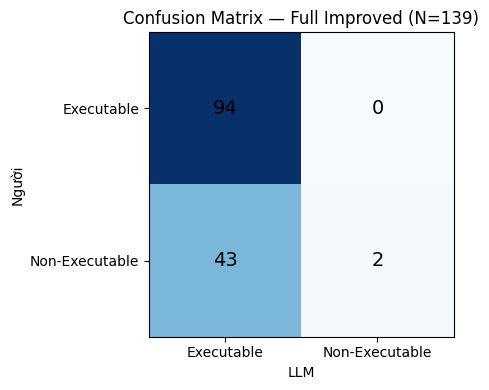

In [4]:

y_true = merged['human_label']
y_pred = merged['llm_label']
labels = ['Executable', 'Non-Executable']

tp = ((y_true=='Non-Executable') & (y_pred=='Non-Executable')).sum()
fn = ((y_true=='Non-Executable') & (y_pred=='Executable')).sum()
fp = ((y_true=='Executable') & (y_pred=='Non-Executable')).sum()
tn = ((y_true=='Executable') & (y_pred=='Executable')).sum()

print("Đếm tay:")
print(f"  Human=Non-Executable, LLM=Non-Executable : {tp}")
print(f"  Human=Non-Executable, LLM=Executable     : {fn}")
print(f"  Human=Executable,     LLM=Non-Executable : {fp}")
print(f"  Human=Executable,     LLM=Executable     : {tn}")
print(f"  Tổng: {tp+fn+fp+tn} (phải = N = {N})")

cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"human: {l}" for l in labels], columns=[f"llm: {l}" for l in labels])
print("\nĐối chiếu sklearn:")
print(cm_df)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_xticklabels(labels)
ax.set_yticks([0,1]); ax.set_yticklabels(labels)
ax.set_xlabel('LLM'); ax.set_ylabel('Người')
ax.set_title(f'Confusion Matrix — Full Improved (N={N})')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', color='black', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Cohen's Kappa (RQ1/SQ1) 

In [5]:

po = (tp + tn) / N
p_h_ne = (y_true == 'Non-Executable').mean()
p_l_ne = (y_pred == 'Non-Executable').mean()
pe = p_h_ne * p_l_ne + (1-p_h_ne) * (1-p_l_ne)
kappa_manual = (po - pe) / (1 - pe)
kappa_sklearn = cohen_kappa_score(y_true, y_pred, labels=labels)

print(f"po (observed agreement) = {po:.4f}")
print(f"pe (expected by chance) = {pe:.4f}")
print(f"Cohen's Kappa (tính tay) = {kappa_manual:.4f}")
print(f"Cohen's Kappa (sklearn)  = {kappa_sklearn:.4f}")
assert abs(kappa_manual - kappa_sklearn) < 1e-9
print("=> Hai cách tính khớp nhau tuyệt đối.")

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label='Non-Executable', zero_division=0)
rec = recall_score(y_true, y_pred, pos_label='Non-Executable', zero_division=0)
print(f"\nAccuracy: {acc:.4f} | Precision(Non-Exec): {prec:.4f} | Recall(Non-Exec): {rec:.4f}")


po (observed agreement) = 0.6906
pe (expected by chance) = 0.6712
Cohen's Kappa (tính tay) = 0.0592
Cohen's Kappa (sklearn)  = 0.0592
=> Hai cách tính khớp nhau tuyệt đối.

Accuracy: 0.6906 | Precision(Non-Exec): 1.0000 | Recall(Non-Exec): 0.0444


In [6]:

rng = np.random.default_rng(42)
n_boot = 5000
boot_kappas = []
for _ in range(n_boot):
    idx = rng.integers(0, N, N)
    yt, yp = y_true.values[idx], y_pred.values[idx]
    if len(set(yt)) < 2 and len(set(yp)) < 2:
        continue
    boot_kappas.append(cohen_kappa_score(yt, yp, labels=labels))
ci_low, ci_high = np.percentile(boot_kappas, [2.5, 97.5])
print(f"Cohen's Kappa 95% CI (bootstrap, seed=42, n={n_boot}): [{ci_low:.4f}, {ci_high:.4f}]")


Cohen's Kappa 95% CI (bootstrap, seed=42, n=5000): [0.0000, 0.1491]


## 6. Statistical test (α = 0.05)


In [7]:

result_mcnemar = mcnemar(cm, exact=(N < 25))
print(f"McNemar's test: statistic = {result_mcnemar.statistic:.4f}, p-value = {result_mcnemar.pvalue:.6f}")
alpha = 0.05
h0_rejected = result_mcnemar.pvalue < alpha
print(f"alpha = {alpha}")
print(f"Reject H0 (không có sai lệch hệ thống giữa LLM và người)? {'CÓ' if h0_rejected else 'KHÔNG'}")


McNemar's test: statistic = 41.0233, p-value = 0.000000
alpha = 0.05
Reject H0 (không có sai lệch hệ thống giữa LLM và người)? CÓ


## 7. Effect size (Cohen's g cho McNemar)

g = |c/(b+c) − 0.5|, trong đó b, c là 2 ô bất đồng trong bảng 2x2.


In [8]:

b = cm[0, 1]  # human=Executable, llm=Non-Executable
c = cm[1, 0]  # human=Non-Executable, llm=Executable
n_discordant = b + c
cohens_g = abs(c / n_discordant - 0.5) if n_discordant > 0 else 0.0

print(f"Discordant pairs: b={b}, c={c}, tổng={n_discordant}")
print(f"Cohen's g = {cohens_g:.4f}")
print("Diễn giải Cohen's g: nhỏ (~0.05), trung bình (~0.15), lớn (~0.25)")


Discordant pairs: b=0, c=43, tổng=43
Cohen's g = 0.5000
Diễn giải Cohen's g: nhỏ (~0.05), trung bình (~0.15), lớn (~0.25)


## 8. Kết luận RQ1 / SQ1 (Improved)

In [9]:

def landis_koch(k):
    if k < 0: return "kém (poor)"
    if k < 0.20: return "rất thấp (slight)"
    if k < 0.40: return "thấp (fair)"
    if k < 0.60: return "trung bình (moderate)"
    if k < 0.80: return "đáng kể (substantial)"
    return "gần hoàn hảo (almost perfect)"

print("="*60)
print("KẾT LUẬN RQ1 / SQ1 — BỘ IMPROVED")
print("="*60)
print(f"N                          : {N}")
print(f"Cohen's Kappa              : {kappa_manual:.4f}  (95% CI [{ci_low:.4f}, {ci_high:.4f}])")
print(f"Diễn giải (Landis & Koch)  : {landis_koch(kappa_manual)}")
print(f"Ngưỡng thành công proposal : kappa >= 0.70")
print(f"Kết quả                    : {'ĐẠT' if kappa_manual >= 0.70 else 'KHÔNG ĐẠT'} ngưỡng")
print(f"McNemar's test p-value     : {result_mcnemar.pvalue:.6f} (alpha={alpha})")
print(f"H0 (không sai lệch hệ thống): {'REJECT' if h0_rejected else 'FAIL TO REJECT'}")
print(f"Effect size (Cohen's g)    : {cohens_g:.4f}")


KẾT LUẬN RQ1 / SQ1 — BỘ IMPROVED
N                          : 139
Cohen's Kappa              : 0.0592  (95% CI [0.0000, 0.1491])
Diễn giải (Landis & Koch)  : rất thấp (slight)
Ngưỡng thành công proposal : kappa >= 0.70
Kết quả                    : KHÔNG ĐẠT ngưỡng
McNemar's test p-value     : 0.000000 (alpha=0.05)
H0 (không sai lệch hệ thống): REJECT
Effect size (Cohen's g)    : 0.5000
